## Flow-Shop Scheduling Problem:
Projeto da Disciplina de Projeto e Análise de Algoritmos

### Importações

In [4]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import time

from fssp_meta_heuristica import FsspSolver

In [5]:
with open('../data/instancias.json', 'r', encoding='utf-8') as arquivo:
    dados = json.load(arquivo)
data = pd.DataFrame(dados.get("instancias"))

print(dados.get("metadata"))
data.head()

{'total_instancias': 31, 'tipo_problema': 'Flow Shop Scheduling'}


,nome_instancia,num_jobs,num_machines,matriz_tempos
0,car1,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278..."
1,car2,13,4,"[[654, 147, 345, 447], [321, 520, 789, 702], [..."
2,car3,12,5,"[[456, 537, 123, 214, 234], [789, 854, 225, 52..."
3,car4,14,4,"[[456, 856, 963, 696], [789, 930, 21, 320], [6..."
4,car5,10,6,"[[333, 991, 996, 123, 145, 234], [333, 111, 66..."


### Filtragem:

In [6]:
data["num_jobs"].value_counts()

num_jobs
20     10
30      6
50      3
75      3
8       2
12      1
13      1
11      1
14      1
100     1
10      1
7       1
Name: count, dtype: int64

In [7]:
data_teste = data

In [8]:
data_teste.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   nome_instancia  31 non-null     object
 1   num_jobs        31 non-null     int64 
 2   num_machines    31 non-null     int64 
 3   matriz_tempos   31 non-null     object
dtypes: int64(2), object(2)
memory usage: 1.1+ KB


### Execução

In [3]:
# tamanho_populacao, numero_geracoes, taxa_crossover, taxa_mutacao
parametros = [(10,10,0.2, 0.1), (20,10,0.2, 0.1), (10,20,0.2, 0.1), (10,10,0.2, 0.1), (10,10,0.4, 0.1), (10,10,0.2, 0.2)]

#### NEH

In [17]:
resultados = []

for indice, linha in data_teste.iterrows():
    for exec in range(20):
        nome = linha["nome_instancia"]
        num_trabalhos = linha["num_jobs"]
        num_maquinas = linha["num_machines"]
        tempos_de_trabalho = linha["matriz_tempos"]

        solver = FsspSolver(num_trabalhos, num_maquinas, tempos_de_trabalho)
        inicio = time.perf_counter()
        solucao, makespan = solver.run("neh")
        fim = time.perf_counter()
    
        resultado = {
            "nome_instancia": nome,
            "execucao": exec,
            "num_tarefas": num_trabalhos,
            "num_maquinas": num_maquinas,
            "matriz_tempos": tempos_de_trabalho, 
            "solucao": solucao,
            "makespan": makespan,
            "tempo": fim-inicio,
            "algoritmo": "NEH"
        }
    
        resultados.append(resultado)

In [18]:
resultados = pd.DataFrame(resultados)
resultados.head(20)

,nome_instancia,execucao,num_tarefas,num_maquinas,matriz_tempos,solucao,makespan,tempo,algoritmo
0,car1,0,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.007288,NEH
1,car1,1,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.006450,NEH
2,car1,2,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.007244,NEH
3,car1,3,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.008224,NEH
4,car1,4,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.005556,NEH
5,car1,5,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.006739,NEH
6,car1,6,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.006103,NEH
7,car1,7,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.005517,NEH
8,car1,8,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.008320,NEH
9,car1,9,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.005124,NEH


In [19]:
resultados.to_csv("../data/resultados_fssp_neh.csv", index=False)

#### Genético

In [20]:
resultados = []
for pop, ger, cros, mut in parametros:
    for indice, linha in data_teste.iterrows():
        for exec in range(20):
            nome = linha["nome_instancia"]
            num_trabalhos = linha["num_jobs"]
            num_maquinas = linha["num_machines"]
            tempos_de_trabalho = linha["matriz_tempos"]

            solver = FsspSolver(num_trabalhos, num_maquinas, tempos_de_trabalho)
            inicio = time.perf_counter()
            solucao, makespan = solver.run("genetico", pop, ger, cros, mut)
            fim = time.perf_counter()

            resultado = {
                "nome_instancia": nome,
                "execucao": exec,
                "num_tarefas": num_trabalhos,
                "num_maquinas": num_maquinas,
                "matriz_tempos": tempos_de_trabalho, 
                "solucao": solucao,
                "makespan": makespan,
                "tempo": fim-inicio,
                "algoritmo": f"Genético-p{pop}-g{ger}-c{100*cros}%-m{100*mut}%"
            }

            resultados.append(resultado)

In [21]:
resultados = pd.DataFrame(resultados)
resultados.head(20)

,nome_instancia,execucao,num_tarefas,num_maquinas,matriz_tempos,solucao,makespan,tempo,algoritmo
0,car1,0,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.078462,Genético-p10-g10-c20.0%-m10.0%
1,car1,1,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.073500,Genético-p10-g10-c20.0%-m10.0%
2,car1,2,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.062164,Genético-p10-g10-c20.0%-m10.0%
3,car1,3,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.059905,Genético-p10-g10-c20.0%-m10.0%
4,car1,4,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.063642,Genético-p10-g10-c20.0%-m10.0%
5,car1,5,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.061118,Genético-p10-g10-c20.0%-m10.0%
6,car1,6,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.057768,Genético-p10-g10-c20.0%-m10.0%
7,car1,7,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.058107,Genético-p10-g10-c20.0%-m10.0%
8,car1,8,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.057498,Genético-p10-g10-c20.0%-m10.0%
9,car1,9,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.058351,Genético-p10-g10-c20.0%-m10.0%


In [22]:
resultados.to_csv("../data/resultados_fssp_genetico.csv", index=False)

#### Memético

In [9]:
import gc
import os
import time
import pandas as pd

memetico = "../data/resultados_fssp_memetico.csv"

In [ ]:
for pop, ger, cros, mut in parametros:
    for indice, linha in data_teste.iterrows():
        print(f"Rodando Memético | Param: p{pop}-g{ger}-c{cros}-m{mut} | Instância: {linha['nome_instancia']}...", end=" ", flush=True)
        
        resultados_parciais = []
        
        for exec in range(20):
            nome = linha["nome_instancia"]
            num_trabalhos = linha["num_jobs"]
            num_maquinas = linha["num_machines"]
            tempos_de_trabalho = linha["matriz_tempos"]

            solver = FsspSolver(num_trabalhos, num_maquinas, tempos_de_trabalho)
            
            # --- faixa de gaza da ram (o que tava matando a ram do notebook de ryan gameplays (tadinho)) ---
            inicio = time.perf_counter()
            solucao, makespan = solver.run("memetico", pop, ger, cros, mut)
            fim = time.perf_counter()
            # --- fim da faixa de gaza ---

            resultado = {
                "nome_instancia": nome,
                "execucao": exec,
                "num_tarefas": num_trabalhos,
                "num_maquinas": num_maquinas,
                "matriz_tempos": tempos_de_trabalho, 
                "solucao": solucao,
                "makespan": makespan,
                "tempo": fim - inicio,
                "algoritmo": f"Memético-p{pop}-g{ger}-c{100*cros}%-m{100*mut}%"
            }
            resultados_parciais.append(resultado)
            
            # Deleta explicitamente a instância do solver para liberar RAM
            del solver 
            
        df_parcial = pd.DataFrame(resultados_parciais)
    
        if not os.path.isfile(memetico):
            df_parcial.to_csv(memetico, index=False)
        else:
            df_parcial.to_csv(memetico, mode='a', header=False, index=False)
            
        print("Salvo!")
        
        # Força o coletor de lixo do Python a limpar a memória RAM
        gc.collect()

Rodando Memético | Param: p10-g10-c0.2-m0.1 | Instância: car1... Salvo!
Rodando Memético | Param: p10-g10-c0.2-m0.1 | Instância: car2... Salvo!
Rodando Memético | Param: p10-g10-c0.2-m0.1 | Instância: car3... Salvo!
Rodando Memético | Param: p10-g10-c0.2-m0.1 | Instância: car4... Salvo!
Rodando Memético | Param: p10-g10-c0.2-m0.1 | Instância: car5... Salvo!
Rodando Memético | Param: p10-g10-c0.2-m0.1 | Instância: car6... Salvo!
Rodando Memético | Param: p10-g10-c0.2-m0.1 | Instância: car7... Salvo!
Rodando Memético | Param: p10-g10-c0.2-m0.1 | Instância: car8... Salvo!
Rodando Memético | Param: p10-g10-c0.2-m0.1 | Instância: hel1... Salvo!
Rodando Memético | Param: p10-g10-c0.2-m0.1 | Instância: hel2... Salvo!
Rodando Memético | Param: p10-g10-c0.2-m0.1 | Instância: reC01... Salvo!
Rodando Memético | Param: p10-g10-c0.2-m0.1 | Instância: reC03... Salvo!
Rodando Memético | Param: p10-g10-c0.2-m0.1 | Instância: reC05... Salvo!
Rodando Memético | Param: p10-g10-c0.2-m0.1 | Instância: reC0

In [ ]:
# resultados = []
# for pop, ger, cros, mut in parametros:
#     for indice, linha in data_teste.iterrows():
#         for exec in range(20):
#             nome = linha["nome_instancia"]
#             num_trabalhos = linha["num_jobs"]
#             num_maquinas = linha["num_machines"]
#             tempos_de_trabalho = linha["matriz_tempos"]

#             solver = FsspSolver(num_trabalhos, num_maquinas, tempos_de_trabalho)
#             inicio = time.perf_counter()
#             solucao, makespan = solver.run("memetico", pop, ger, cros, mut)
#             fim = time.perf_counter()

#             resultado = {
#                 "nome_instancia": nome,
#                 "execucao": exec,
#                 "num_tarefas": num_trabalhos,
#                 "num_maquinas": num_maquinas,
#                 "matriz_tempos": tempos_de_trabalho, 
#                 "solucao": solucao,
#                 "makespan": makespan,
#                 "tempo": fim-inicio,
#                 "algoritmo": f"Memético-p{pop}-g{ger}-c{100*cros}%-m{100*mut}%"
#             }

#             resultados.append(resultado)

In [ ]:
resultados = pd.DataFrame(resultados)
resultados.head(20)

In [ ]:
resultados.to_csv("../data/resultados_fssp_memetico.csv", index=False)

#### Final

In [12]:
arquivos = ['../data/resultados_fssp_neh.csv', '../data/resultados_fssp_genetico.csv', '../data/resultados_fssp_memetico.csv']
df_final = pd.concat(
    [pd.read_csv(arquivo) for arquivo in arquivos], 
    ignore_index=True
)

estatisticas = df_final.groupby(['algoritmo', 'nome_instancia'])['tempo'].agg([
    ('tempo_medio', 'mean'),
    ('tempo_std', 'std'),
    ('tempo_min', 'min'),
    ('tempo_max', 'max'),
    ('tempo_mediana', 'median')
]).reset_index()

df_final = df_final.merge(estatisticas, on=['algoritmo', 'nome_instancia'], how='left')
df_final['grupo'] = df_final['nome_instancia'].str.extract(r'^([a-zA-Z]+)')

df_final.to_csv("../data/resultados_fssp_mh.csv", index=False)

### Análise dos dados

In [13]:
df = pd.read_csv("../data/resultados_fssp_mh.csv")
df.head()

,nome_instancia,execucao,num_tarefas,num_maquinas,matriz_tempos,solucao,makespan,tempo,algoritmo,tempo_medio,tempo_std,tempo_min,tempo_max,tempo_mediana,grupo
0,car1,0,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.007288,NEH,0.006752,0.001216,0.005124,0.00967,0.00658,car
1,car1,1,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.006450,NEH,0.006752,0.001216,0.005124,0.00967,0.00658,car
2,car1,2,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.007244,NEH,0.006752,0.001216,0.005124,0.00967,0.00658,car
3,car1,3,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.008224,NEH,0.006752,0.001216,0.005124,0.00967,0.00658,car
4,car1,4,11,5,"[[375, 12, 142, 245, 412], [632, 452, 758, 278...","[7, 0, 4, 8, 2, 10, 3, 6, 5, 1, 9]",7038.0,0.005556,NEH,0.006752,0.001216,0.005124,0.00967,0.00658,car


#### Tempos

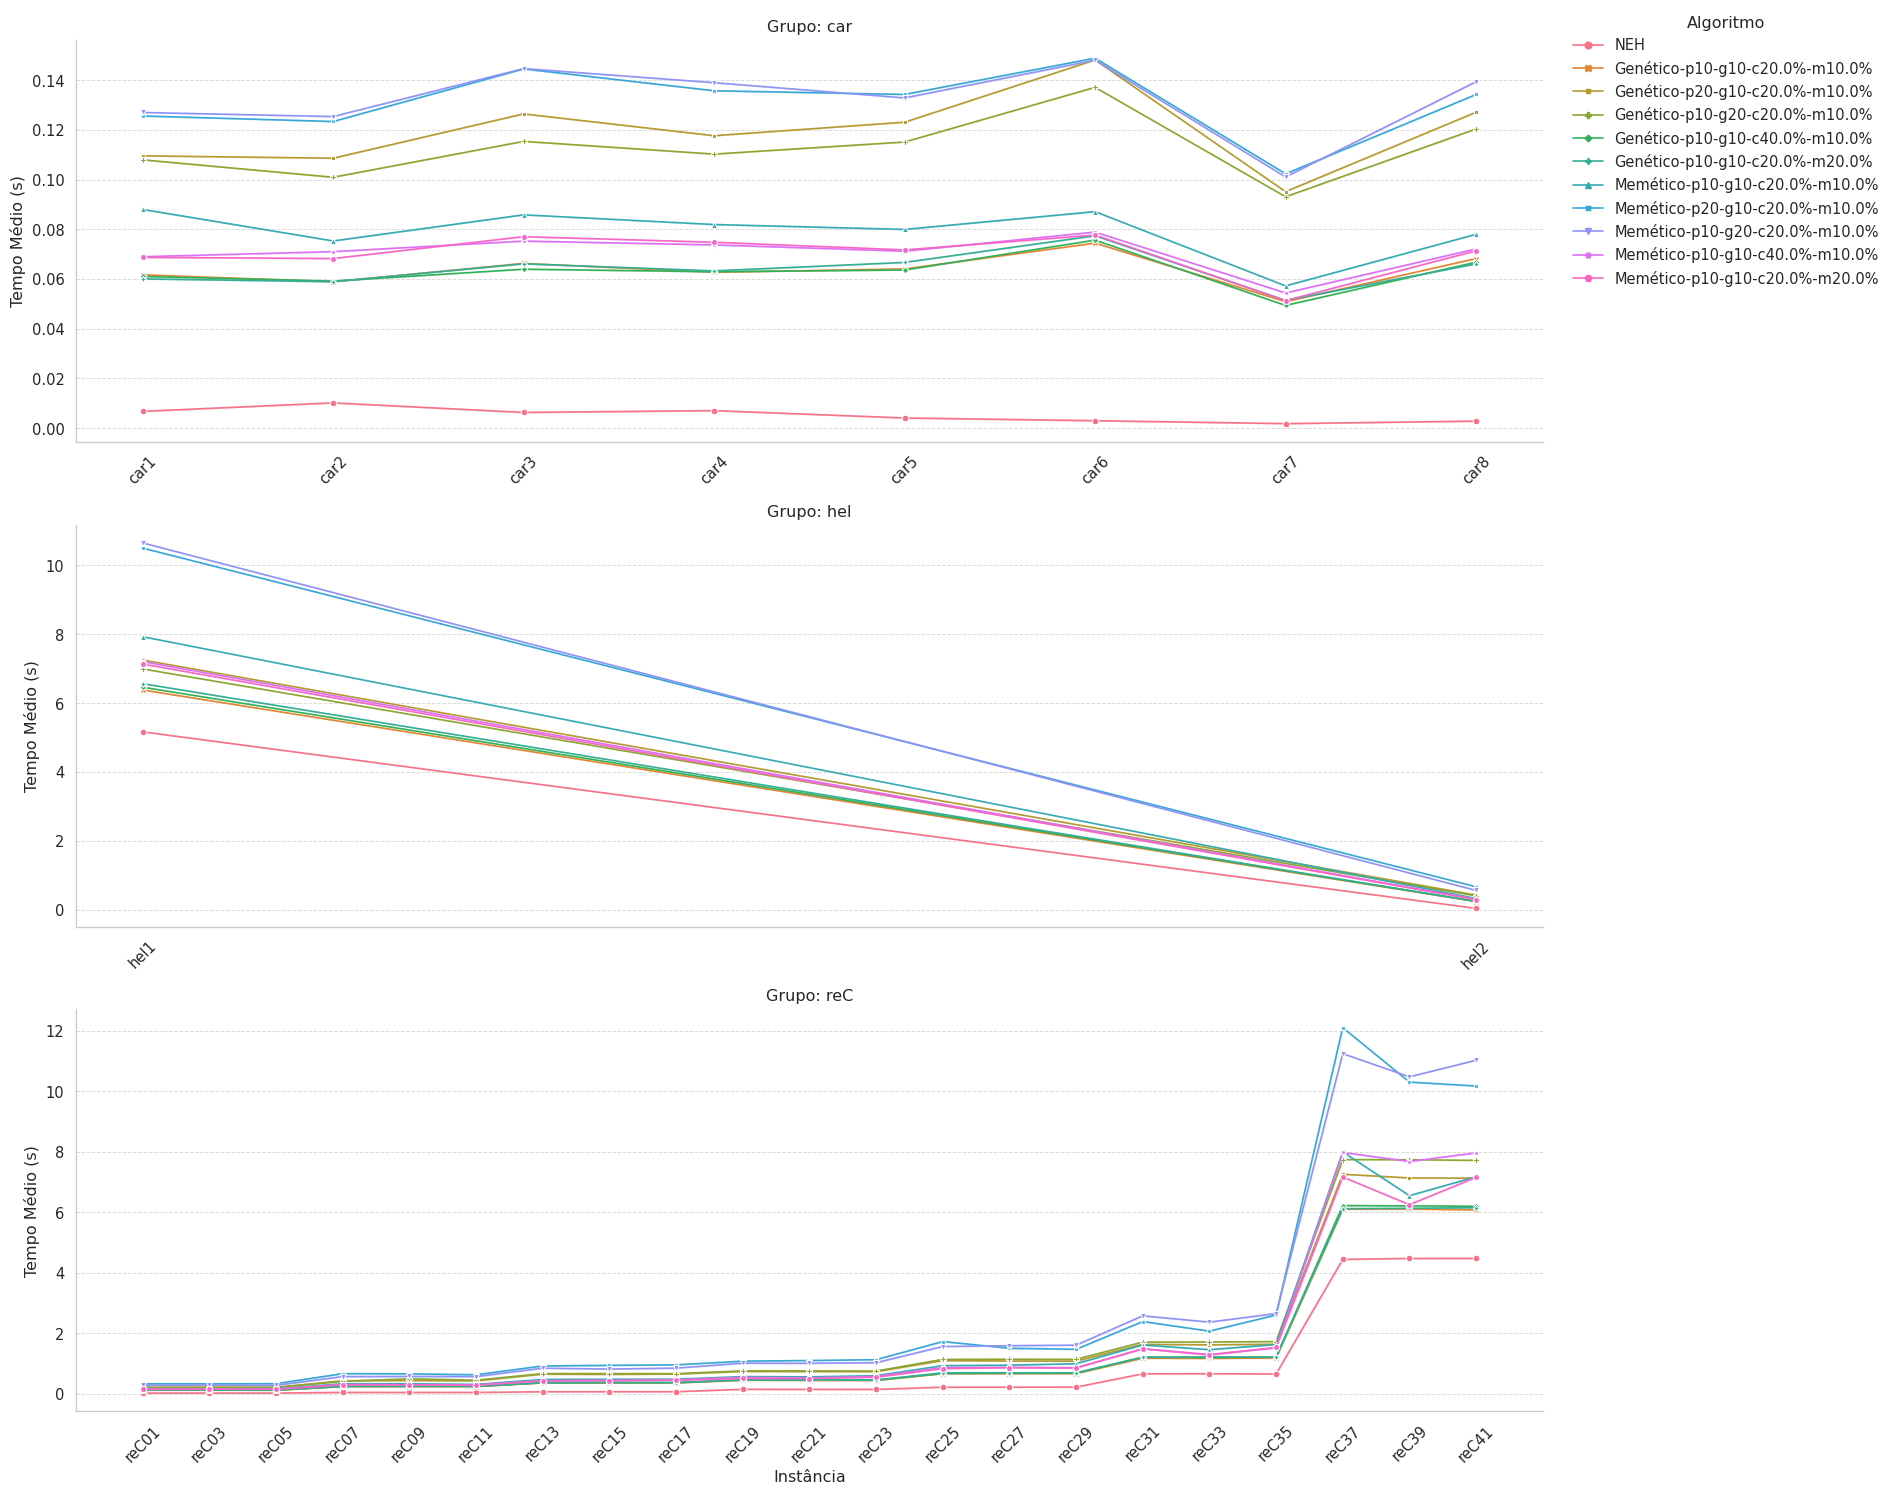

In [14]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
palette = sns.color_palette("husl", n_colors=len(df['algoritmo'].unique()))

fig = sns.relplot(
    data=df,
    x="nome_instancia",
    y="tempo_medio",
    hue="algoritmo",
    style="algoritmo",
    col="grupo",
    col_wrap=1,
    markers=True,
    dashes=False,
    kind="line",
    palette=palette,
    height=5,
    aspect=2.5,
    facet_kws={'sharex': False, 'sharey': False}
)

fig.set_titles("Grupo: {col_name}")
fig.set_axis_labels("Instância", "Tempo Médio (s)")

for ax in fig.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, axis='y', linestyle='--', linewidth=0.7, alpha=0.7)
    ax.grid(False, axis='x')

sns.move_legend(
    fig, "upper left", 
    bbox_to_anchor=(1, 1),
    title='Algoritmo',
    frameon=False,
)

plt.tight_layout()
plt.show()

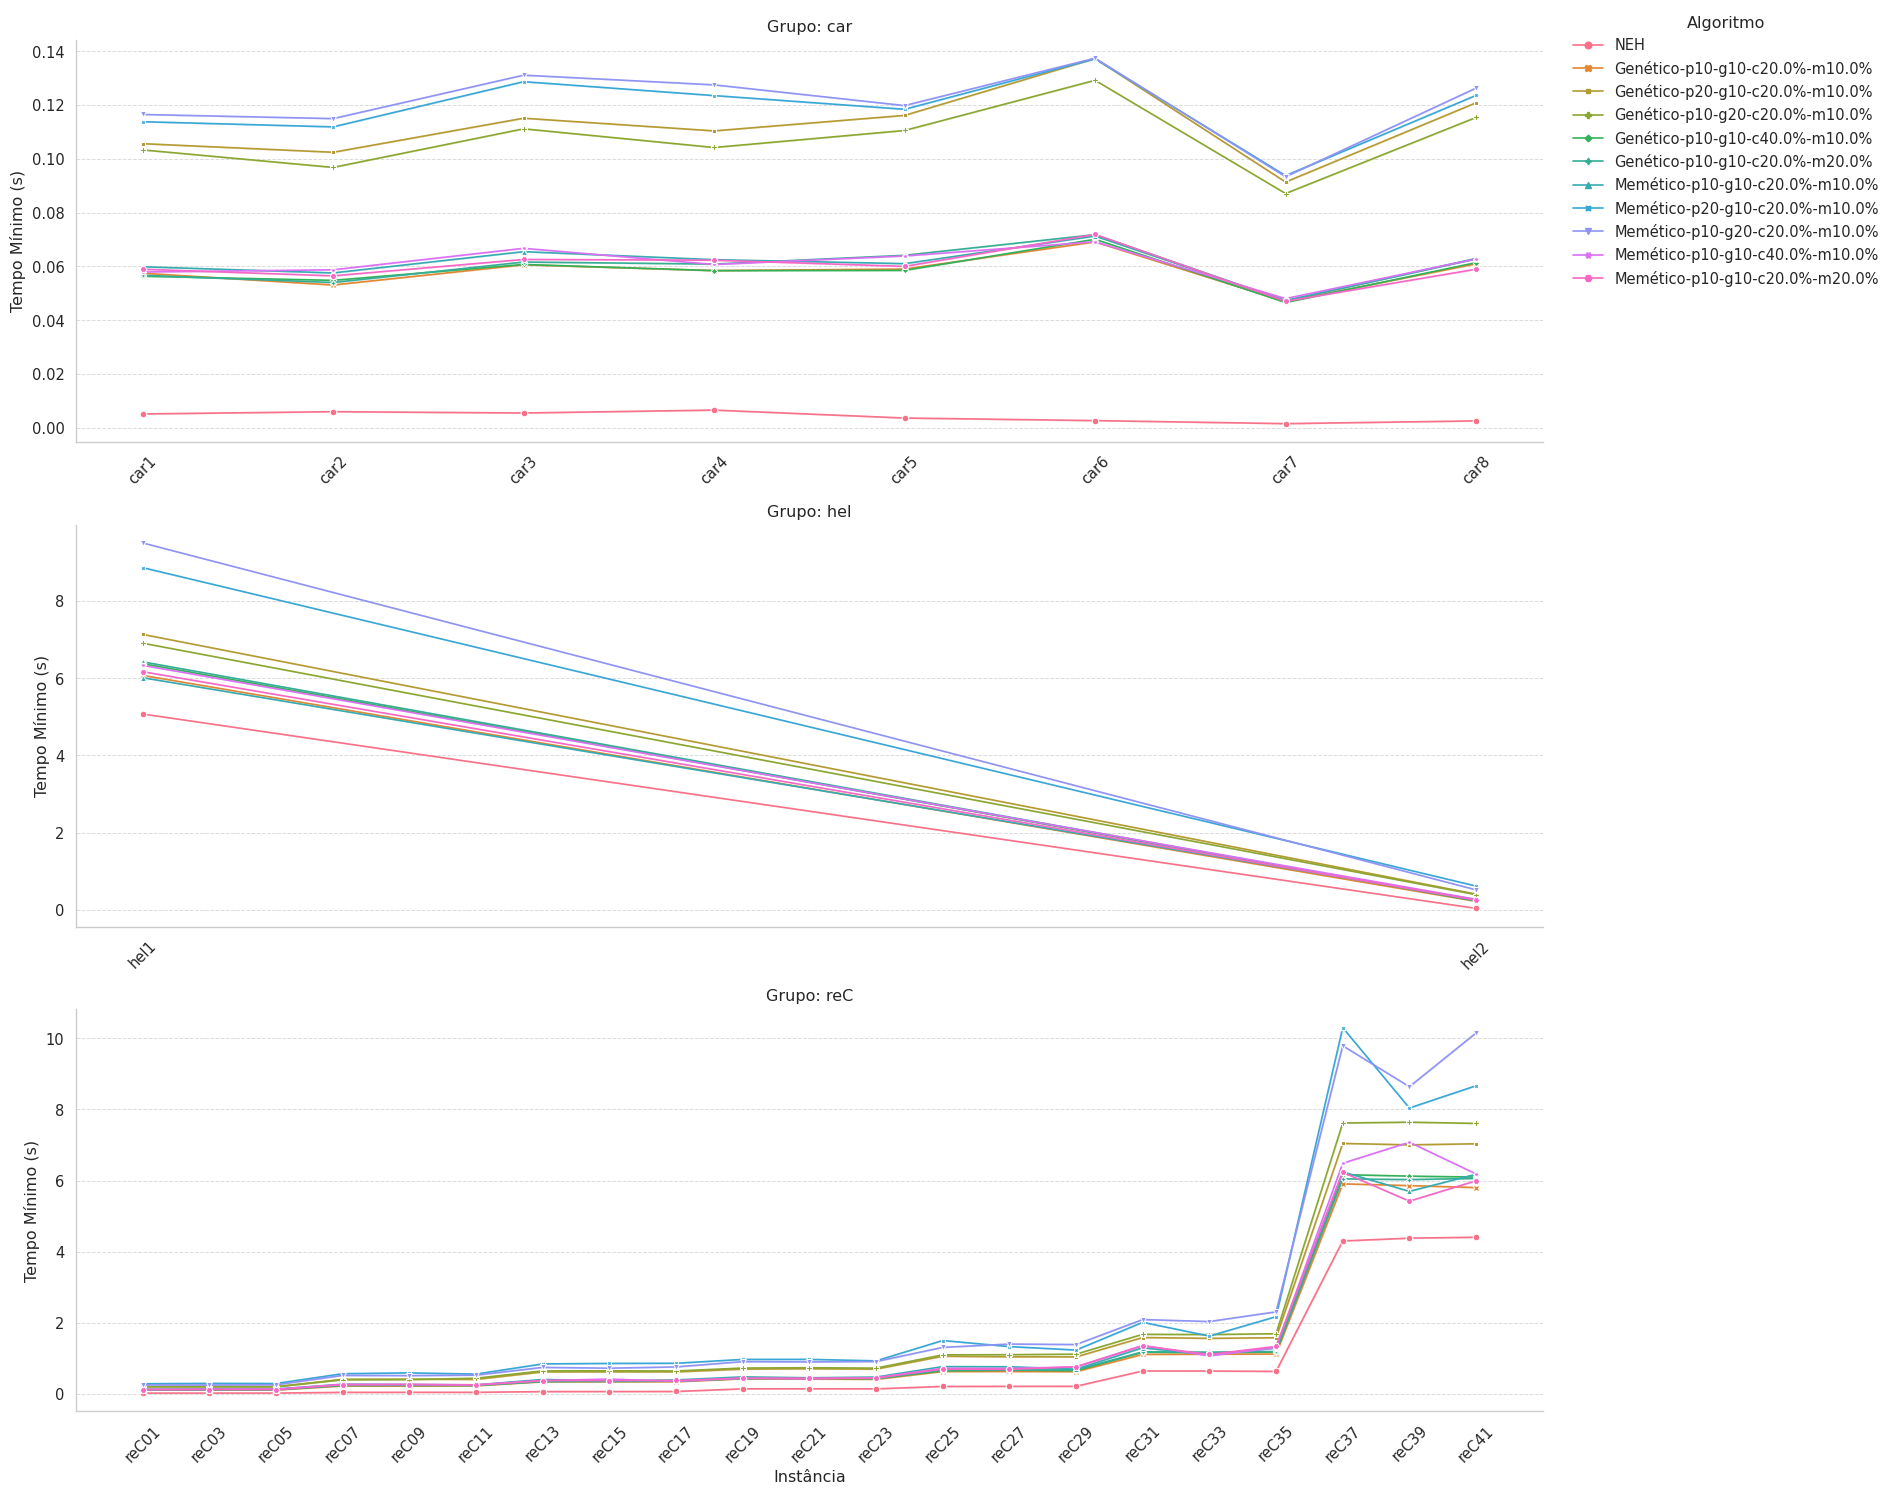

In [15]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
palette = sns.color_palette("husl", n_colors=len(df['algoritmo'].unique()))

fig = sns.relplot(
    data=df,
    x="nome_instancia",
    y="tempo_min",
    hue="algoritmo",
    style="algoritmo",
    col="grupo",
    col_wrap=1,
    markers=True,
    dashes=False,
    kind="line",
    palette=palette,
    height=5,
    aspect=2.5,
    facet_kws={'sharex': False, 'sharey': False}
)

fig.set_titles("Grupo: {col_name}")
fig.set_axis_labels("Instância", "Tempo Mínimo (s)")

for ax in fig.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, axis='y', linestyle='--', linewidth=0.7, alpha=0.7)
    ax.grid(False, axis='x')

sns.move_legend(
    fig, "upper left", 
    bbox_to_anchor=(1, 1),
    title='Algoritmo',
    frameon=False,
)

plt.tight_layout()
plt.show()

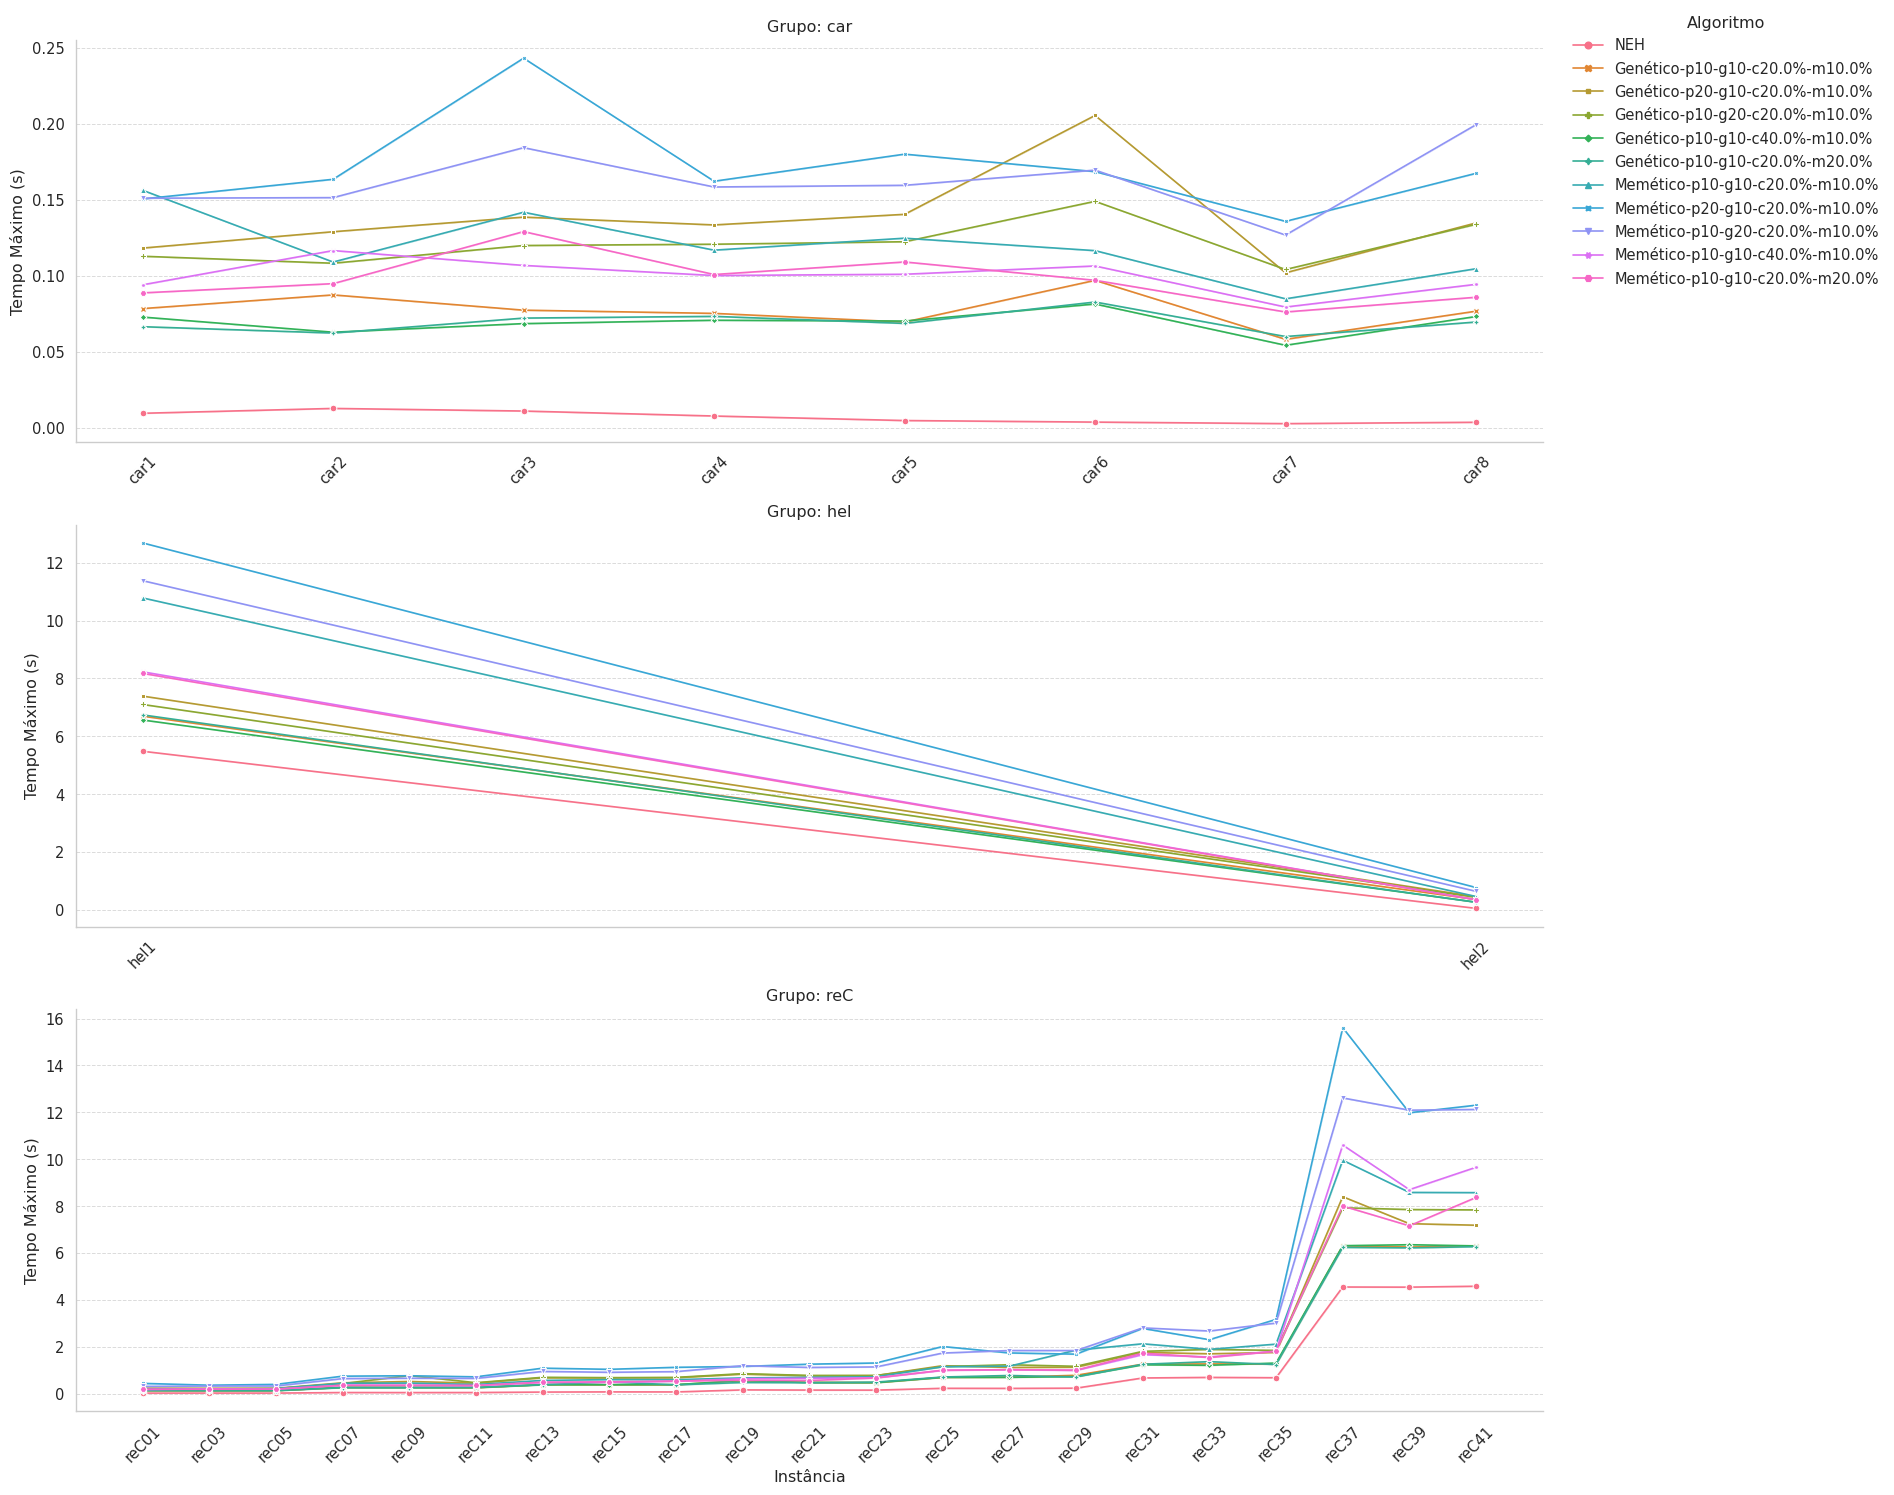

In [16]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
palette = sns.color_palette("husl", n_colors=len(df['algoritmo'].unique()))

fig = sns.relplot(
    data=df,
    x="nome_instancia",
    y="tempo_max",
    hue="algoritmo",
    style="algoritmo",
    col="grupo",
    col_wrap=1,
    markers=True,
    dashes=False,
    kind="line",
    palette=palette,
    height=5,
    aspect=2.5,
    facet_kws={'sharex': False, 'sharey': False}
)

fig.set_titles("Grupo: {col_name}")
fig.set_axis_labels("Instância", "Tempo Máximo (s)")

for ax in fig.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, axis='y', linestyle='--', linewidth=0.7, alpha=0.7)
    ax.grid(False, axis='x')

sns.move_legend(
    fig, "upper left", 
    bbox_to_anchor=(1, 1),
    title='Algoritmo',
    frameon=False,
)

plt.tight_layout()
plt.show()

#### Makespan

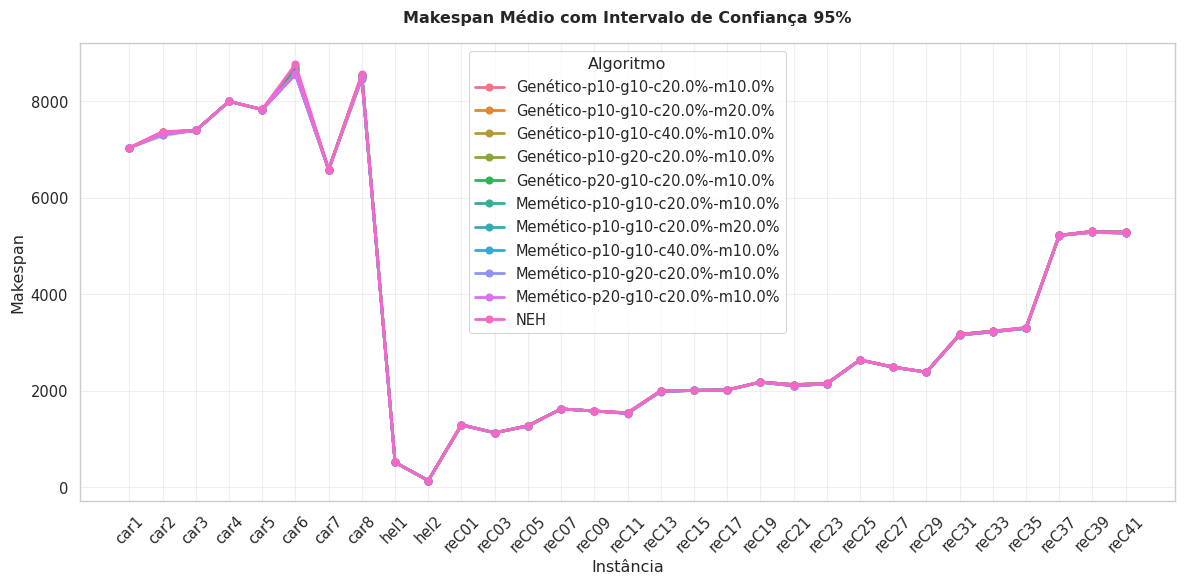

In [17]:
df_grouped = df.groupby(['nome_instancia', 'algoritmo']).agg({
    'makespan': ['mean', 'std', 'min', 'max', 'count']
}).reset_index()

df_grouped.columns = ['nome_instancia', 'algoritmo', 'media', 'desvio_padrao', 
                      'minimo', 'maximo', 'n_execucoes']

df_grouped['erro'] = 1.96 * df_grouped['desvio_padrao'] / np.sqrt(df_grouped['n_execucoes'])
df_grouped['intervalo_superior'] = df_grouped['media'] + df_grouped['erro']
df_grouped['intervalo_inferior'] = df_grouped['media'] - df_grouped['erro']

fig, ax = plt.subplots(figsize=(12, 6))

algoritmos = df_grouped['algoritmo'].unique()
palette = sns.color_palette('husl', len(algoritmos))

for i, alg in enumerate(algoritmos):
    df_alg = df_grouped[df_grouped['algoritmo'] == alg].sort_values('nome_instancia')
    
    ax.plot(df_alg['nome_instancia'], df_alg['media'], 
            label=alg, color=palette[i], marker='o', linewidth=2)
    
    ax.fill_between(df_alg['nome_instancia'], 
                    df_alg['intervalo_inferior'], 
                    df_alg['intervalo_superior'],
                    alpha=0.2, color=palette[i])

ax.set_title('Makespan Médio com Intervalo de Confiança 95%', fontweight='bold', pad=15)
ax.set_xlabel('Instância')
ax.set_ylabel('Makespan')
ax.legend(title='Algoritmo', loc='best')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

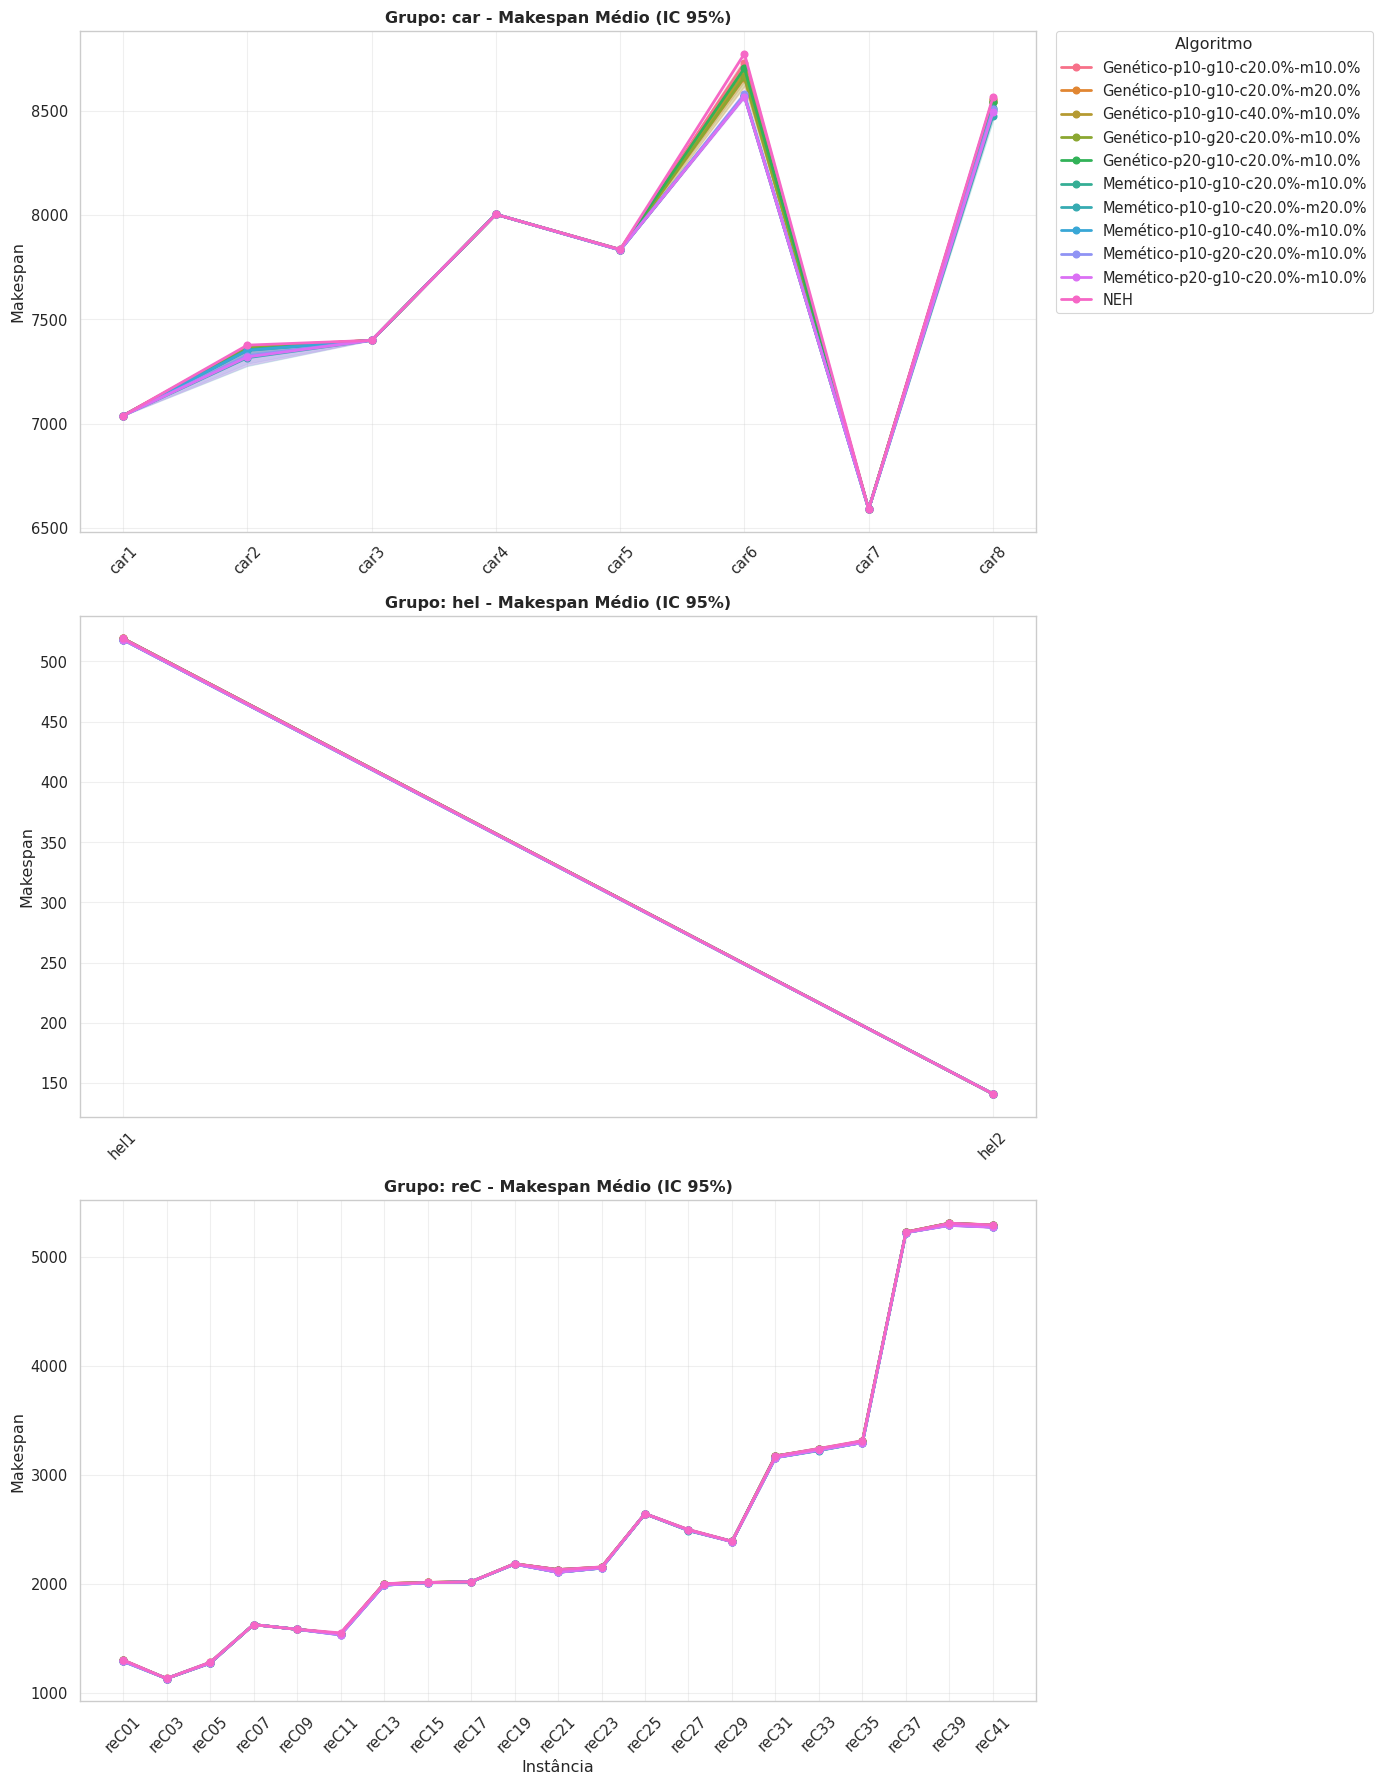

In [18]:
df_grouped['grupo'] = df_grouped['nome_instancia'].str.extract(r'^([a-zA-Z]+)')
grupos_unicos = df_grouped['grupo'].unique()

algoritmos = df_grouped['algoritmo'].unique()
palette = sns.color_palette('husl', len(algoritmos))
color_map = dict(zip(algoritmos, palette))

fig, axes = plt.subplots(nrows=len(grupos_unicos), ncols=1, figsize=(14, 6 * len(grupos_unicos)))

if len(grupos_unicos) == 1:
    axes = [axes]

for ax, grupo in zip(axes, grupos_unicos):
    
    df_fatiado = df_grouped[df_grouped['grupo'] == grupo]
    
    for alg in algoritmos:
        df_alg = df_fatiado[df_fatiado['algoritmo'] == alg].sort_values('nome_instancia')
        
        if df_alg.empty:
            continue
            
        ax.plot(df_alg['nome_instancia'], df_alg['media'], 
                label=alg, color=color_map[alg], marker='o', linewidth=2)
        
        ax.fill_between(df_alg['nome_instancia'], 
                        df_alg['intervalo_inferior'], 
                        df_alg['intervalo_superior'],
                        alpha=0.2, color=color_map[alg])

    ax.set_title(f'Grupo: {grupo} - Makespan Médio (IC 95%)', fontweight='bold')
    ax.set_ylabel('Makespan')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

axes[0].legend(title='Algoritmo', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.xlabel('Instância')
plt.tight_layout()
plt.show()

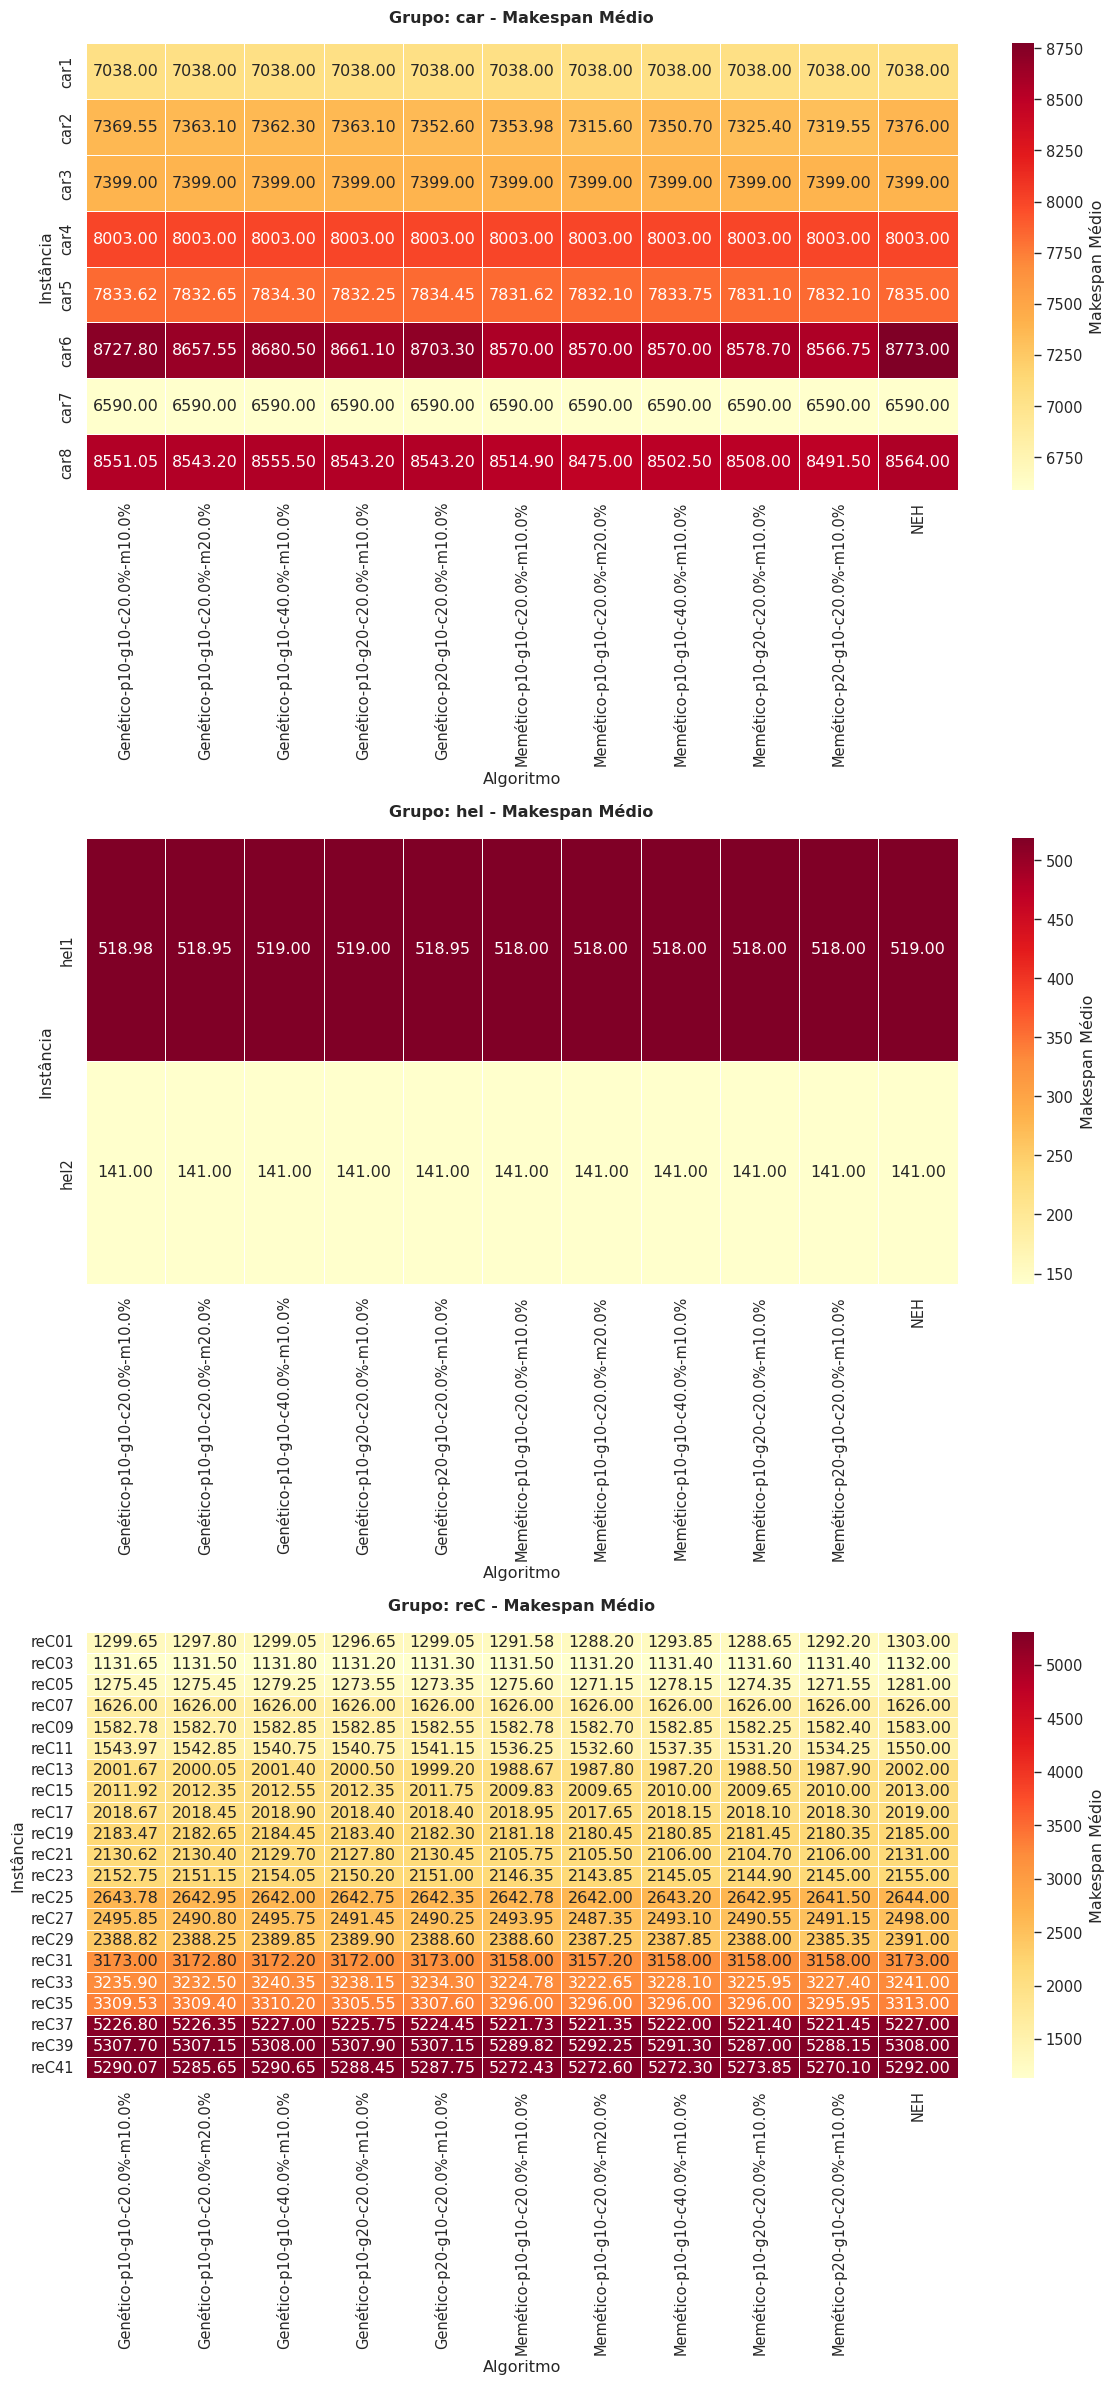

In [19]:
df['grupo'] = df['nome_instancia'].str.extract(r'^([a-zA-Z]+)')
grupos_unicos = df['grupo'].unique()

fig, axes = plt.subplots(nrows=len(grupos_unicos), ncols=1, figsize=(12, 8 * len(grupos_unicos)))

if len(grupos_unicos) == 1:
    axes = [axes]

for ax, grupo in zip(axes, grupos_unicos):
    df_grupo = df[df['grupo'] == grupo]
    
    pivot_table = df_grupo.pivot_table(
        values='makespan',
        index='nome_instancia',
        columns='algoritmo',
        aggfunc='mean'
    )
    sns.heatmap(
        pivot_table,
        annot=True,
        fmt='.2f',
        cmap='YlOrRd',
        linewidths=0.5,
        ax=ax,
        cbar_kws={'label': 'Makespan Médio'}
    )
    
    ax.set_title(f'Grupo: {grupo} - Makespan Médio', fontweight='bold', pad=15)
    ax.set_xlabel('Algoritmo')
    ax.set_ylabel('Instância')
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()